In [145]:
from sklearn.datasets import load_digits
import numpy as np 
from sklearn.cluster import KMeans
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [146]:
X, y = load_digits(return_X_y=True)
X, y

(array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)),
 array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)))

In [147]:
xTrain, yTrain = X[:1400], y[:1400]

xTest, yTest = X[1400:], y[1400:]

xTrain, yTrain, xTest, yTest


(array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  0., ..., 12.,  0.,  0.],
        [ 0.,  0.,  0., ...,  9.,  0.,  0.],
        [ 0.,  0.,  3., ...,  0.,  0.,  0.]], shape=(1400, 64)),
 array([0, 1, 2, ..., 4, 4, 7], shape=(1400,)),
 array([[ 0.,  0.,  7., ..., 16., 16.,  6.],
        [ 0.,  0.,  8., ...,  1.,  0.,  0.],
        [ 0.,  0., 11., ..., 13., 16.,  7.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(397, 64)),
 array([2, 8, 2, 2, 5, 7, 9, 5, 4, 8, 8, 4, 9, 0, 8, 0, 1, 2, 3, 4, 5, 6,
        7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8,
        9, 0, 9, 5, 5, 6, 5, 0, 9, 8, 9, 8, 4, 1, 7, 7, 3, 5, 1, 0, 0, 2,
        2, 7, 8, 2, 0, 1, 2, 6, 3, 3, 7, 3, 3, 4, 6, 6, 6, 4, 9, 1, 5, 0,
        9, 5, 2, 8, 2, 0, 0, 1, 7, 6, 3, 2, 1, 7, 4

In [148]:
baseModel = LogisticRegression(n_jobs=10, max_iter=777_77777, random_state=67)

kMModel = KMeans(n_clusters=400, init="k-means++", max_iter=77_7777777, random_state=67, n_init=777)

In [149]:
xDist = kMModel.fit_transform(xTrain)

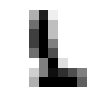

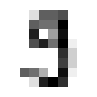

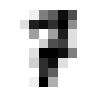

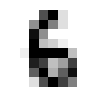

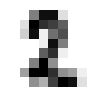

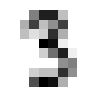

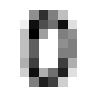

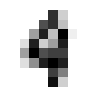

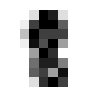

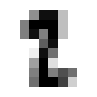

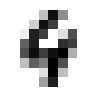

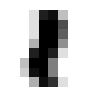

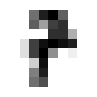

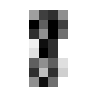

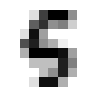

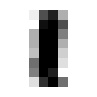

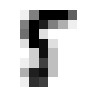

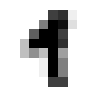

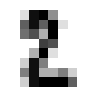

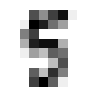

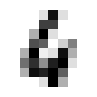

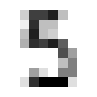

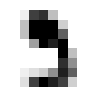

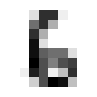

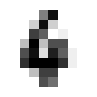

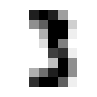

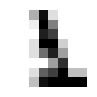

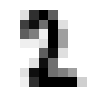

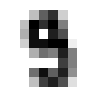

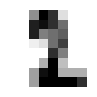

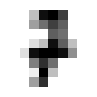

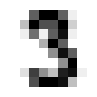

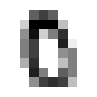

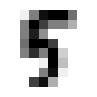

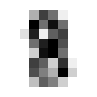

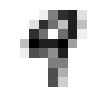

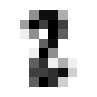

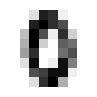

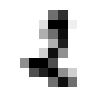

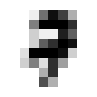

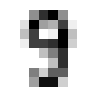

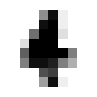

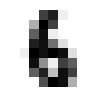

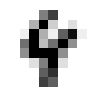

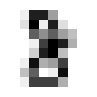

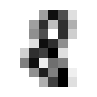

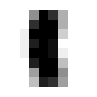

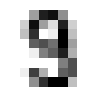

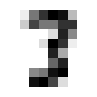

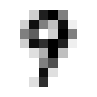

In [150]:
xRepIndex = np.argmin(xDist, axis=0)
xRepresentatives = xTrain[xRepIndex].copy()

for i in range(0, 50, 1):
    img = xRepresentatives[i].reshape(8, 8)
    plt.figure(figsize=(1,1))
    plt.imshow(img, cmap="binary")
    plt.grid(False)
    plt.axis("off")
    plt.show()


In [151]:
yRepresentatives = np.array([1, 9, 7, 6, 2, 3, 0, 4, 8, 2, 4, 1, 7, 8, 5, 1, 5, 1, 2, 5, 4, 5,
       9, 6, 4, 3, 1, 2, 9, 2, 7, 3, 0, 5, 8, 9, 2, 0, 2, 7, 9, 4, 6, 4,
       8, 8, 1, 9, 3, 9, 3, 4, 6, 7, 5, 4, 1, 2, 7, 8, 4, 3, 5, 1, 9, 6,
       7, 0, 3, 7, 2, 6, 4, 5, 9, 7, 4, 0, 3, 7, 2, 8, 2, 9, 2, 5, 8, 7,
       9, 5, 6, 2, 8, 9, 5, 8, 2, 0, 8, 5, 1, 0, 2, 1, 1, 9, 3, 6, 1, 7,
       6, 1, 8, 7, 9, 5, 3, 6, 4, 8, 9, 4, 9, 5, 7, 5, 8, 8, 7, 6, 4, 9,
       2, 7, 6, 8, 1, 6, 7, 5, 8, 5, 1, 0, 6, 8, 6, 1, 7, 7, 4, 6, 9, 2,
       3, 4, 3, 9, 2, 6, 6, 8, 2, 0, 8, 0, 9, 1, 9, 0, 1, 0, 5, 0, 3, 9,
       1, 8, 4, 3, 8, 9, 2, 9, 2, 3, 7, 4, 4, 9, 3, 5, 6, 8, 4, 7, 9, 6,
       4, 3, 9, 4, 8, 9, 8, 5, 0, 3, 1, 7, 5, 7, 0, 3, 2, 2, 7, 3, 8, 6,
       1, 9, 8, 1, 4, 2, 1, 0, 5, 2, 7, 2, 3, 0, 3, 4, 0, 2, 8, 5, 8, 5,
       6, 7, 5, 5, 5, 5, 7, 7, 9, 0, 8, 6, 6, 5, 3, 9, 8, 7, 1, 3, 2, 4,
       4, 8, 3, 3, 8, 4, 3, 7, 5, 8, 6, 2, 4, 8, 2, 1, 5, 7, 9, 6, 9, 7,
       8, 7, 5, 3, 9, 8, 0, 8, 7, 1, 7, 6, 9, 5, 5, 8, 9, 6, 0, 1, 5, 8,
       2, 4, 5, 3, 8, 1, 1, 9, 2, 9, 5, 7, 8, 3, 8, 6, 6, 8, 6, 7, 7, 0,
       8, 5, 7, 2, 3, 8, 3, 9, 9, 2, 5, 0, 7, 3, 7, 4, 4, 3, 3, 4, 8, 8,
       4, 5, 5, 4, 7, 5, 1, 6, 5, 5, 0, 4, 4, 8, 8, 9, 2, 9, 1, 3, 0, 8,
       3, 4, 8, 5, 4, 2, 3, 5, 9, 9, 5, 8, 5, 1, 1, 8, 8, 1, 3, 5, 8, 1,
       9, 2, 3, 0])

baseModel.fit(xRepresentatives, yRepresentatives)
baseModel.score(xTest, yTest)

0.9042821158690176

In [152]:
yPropagate = np.empty(len(yTrain), dtype=np.uint8)
yPropagate

array([ 96,   9, 178, ...,   0,   0,   0], shape=(1400,), dtype=uint8)

In [153]:
kMModel.labels_[xRepIndex]

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [154]:

for i in range(0, 400, 1):
    yPropagate[kMModel.labels_==i] = yRepresentatives[i]

yPropagate, xTrain
    

(array([0, 1, 2, ..., 4, 4, 7], shape=(1400,), dtype=uint8),
 array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  0., ..., 12.,  0.,  0.],
        [ 0.,  0.,  0., ...,  9.,  0.,  0.],
        [ 0.,  0.,  3., ...,  0.,  0.,  0.]], shape=(1400, 64)))

In [155]:
propagatedModel = LogisticRegression(n_jobs=10, max_iter=777_77777, random_state=67)
propagatedModel.fit(xTrain, yPropagate)
propagatedModel.score(xTest, yTest)

0.906801007556675

In [156]:
twoPropagatedModel = XGBClassifier(n_estimators=5_5555, learning_rate=0.001, random_state=67, n_jobs=10)

In [157]:
twoPropagatedModel.fit(xTrain, yPropagate)
twoPropagatedModel.score(xTest, yTest)

0.8816120906801007

In [158]:
nonPropagatedSvcModel = SVC(kernel="rbf", gamma="scale", max_iter=7777_7777, C=50, random_state=67)

In [159]:
nonPropagatedSvcModel.fit(xRepresentatives, yRepresentatives)
nonPropagatedSvcModel.score(xTest, yTest)

0.9445843828715366

In [160]:
threePropagatedModel = SVC(kernel="rbf", gamma="scale", max_iter=7777_7777, C=50, random_state=67)

In [161]:
threePropagatedModel.fit(xTrain, yPropagate)
threePropagatedModel.score(xTest, yTest) # +2% boost through cluster based labels.

0.9672544080604534

In [162]:
fullSvcModel = SVC(kernel="rbf", gamma="scale", max_iter=7777_7777, C=50, random_state=67)

In [163]:
fullSvcModel.fit(xTrain, yTrain)
fullSvcModel.score(xTest, yTest)

0.9596977329974811

In [164]:
fullLogModel = LogisticRegression(n_jobs=10, max_iter=777_77777, random_state=67)
fullLogModel.fit(xTrain, yTrain)
fullLogModel.score(xTest, yTest)

0.9093198992443325